# Online Retail Store Analysis

## Preparing environment

### Loading up needed modules

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
from pathlib import Path

### Importing data

In [2]:
df = pd.read_csv(Path("datasets") / "online_retail.csv")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


In [3]:
df.sample(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
32953,539212,22646,CERAMIC STRAWBERRY CAKE MONEY BANK,12,2010-12-16 12:20:00,1.45,17146.0,United Kingdom
291737,562517,23298,SPOTTY BUNTING,2,2011-08-05 12:27:00,4.95,15719.0,United Kingdom
83833,543354,22251,BIRDHOUSE DECORATION MAGIC GARDEN,12,2011-02-07 13:50:00,1.25,13458.0,United Kingdom
92884,544207,DOT,DOTCOM POSTAGE,1,2011-02-17 10:34:00,185.83,NaN,United Kingdom
400280,571305,22668,PINK BABY BUNTING,1,2011-10-17 09:55:00,5.79,NaN,United Kingdom
179791,552286,22993,SET OF 4 PANTRY JELLY MOULDS,12,2011-05-08 13:07:00,1.25,16393.0,United Kingdom
255603,559357,23298,SPOTTY BUNTING,8,2011-07-07 18:56:00,4.95,17107.0,United Kingdom
385593,570210,84032A,CHARLIE+LOLA PINK HOT WATER BOTTLE,1,2011-10-09 10:48:00,2.95,13259.0,United Kingdom
270898,560601,22614,PACK OF 12 SPACEBOY TISSUES,1,2011-07-19 17:17:00,0.29,16764.0,United Kingdom
196709,553860,21672,WHITE SPOT RED CERAMIC DRAWER KNOB,2,2011-05-19 13:57:00,1.25,17841.0,United Kingdom


# Data preparation

### Checking data completeness

In [ ]:
all_cols = df.columns
bar_colors = []
counted_cols = []
for col_name in all_cols:
    completeness = 1 - len(df.loc[df[col_name].isnull(), col_name]) / len(df)
    counted_cols.append(completeness)
    if completeness == 1.0:
        bar_colors.append("darkgreen")
    elif completeness > 0.8:
        bar_colors.append("gold")
    else:
        bar_colors.append("red")


def percentage_format(x, position):
    return f"{round(x * 100)}%"


fig, axs = plt.subplots(figsize=(len(counted_cols) * 2, 5))
axs.set_title("Data completeness %")
axs.yaxis.set_major_formatter(percentage_format)
axs.bar(all_cols, counted_cols, color=bar_colors)
axs.set_ylim(0, 1)
plt.show()

### Missing Customer Data

As we can see, the dataset lacks `CustomerID` for many records. By dropping these rows, this analysis excludes "guest checkouts". Our focus is strictly on registered users, allowing for a genuine evaluation of customer loyalty, retention metrics, and long-term user behavior.

In [5]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df = df.dropna(subset="CustomerID")

df = df.assign(
    TotalPrice=lambda x: x["UnitPrice"] * x["Quantity"],
    InvoiceMonth=lambda x: x["InvoiceDate"].values.astype("datetime64[M]"),
)

### Data Architecture: Splitting the Dataset

To ensure absolute metric accuracy, we must branch our dataset based on the business question being asked:

1. **Net Revenue & LTV (Full Dataset):** The original dataset includes invoices starting with "C" (cancellations and returns). These are crucial for calculating true Net Lifetime Value (LTV), as returns offset gross revenue.
2. **Customer Retention (Filtered Dataset):** For analyzing user loyalty, we create a separate `df_no_cancel` dataframe excluding cancellations. If we kept returns here, our grouping logic would register a product return in a subsequent month as a new "active shopping session," artificially inflating our retention rates.

In [6]:
df_no_cancel = df[~df["InvoiceNo"].str.startswith("C")]
df_no_cancel = df_no_cancel[
    (df_no_cancel["Quantity"] > 0) & (df_no_cancel["UnitPrice"] > 0)
]

## Cohort analysis

A helper DataFrame called `cohort_map` is used to assign customers to their respective cohorts based on their first purchase month. Crucially, this mapping is derived strictly from successful transactions (excluding cancellations). By establishing this Single Source of Truth for cohort assignment, we can accurately map these cohorts back to the unfiltered dataset, ensuring our financial calculations correctly account for all cash flows, including refunds.

In [7]:
cohort_map = df_no_cancel.groupby("CustomerID").agg(CohortMonth=("InvoiceMonth", "min"))

### Customer Retention

Here, I am creating a new `df_retention` DataFrame, where `CohortIndex` represents the difference in months between the first purchase and subsequent invoices.

Next, to generate a heatmap, I aggregate the number of unique customers acquired in a given month who continue to make purchases in the following months.

In [8]:
df_retention = df_no_cancel.merge(cohort_map, on="CustomerID").assign(
    CohortIndex=lambda x: (
        (x["InvoiceMonth"].dt.year - x["CohortMonth"].dt.year) * 12
        + (x["InvoiceMonth"].dt.month - x["CohortMonth"].dt.month)
    )
)

cohort_data = (
    df_retention.groupby(["CohortMonth", "CohortIndex"])
    .agg({"CustomerID": "nunique"})
    .reset_index()
)
cohort_data

,CohortMonth,CohortIndex,CustomerID
0,2010-12-01,0,885
1,2010-12-01,1,324
2,2010-12-01,2,286
3,2010-12-01,3,340
4,2010-12-01,4,321
...,...,...,...
86,2011-10-01,1,86
87,2011-10-01,2,41
88,2011-11-01,0,323
89,2011-11-01,1,36


Creating the table

In [9]:
cohort_table = pd.pivot(
    cohort_data, columns="CohortIndex", values="CustomerID", index="CohortMonth"
)
cohort_table

CohortIndex,0,1,2,3,4,5,6,7,8,9,10,11,12
CohortMonth,,,,,,,,,,,,,
2010-12-01,885.0,324.0,286.0,340.0,321.0,352.0,321.0,309.0,313.0,350.0,331.0,445.0,235.0
2011-01-01,417.0,92.0,111.0,96.0,134.0,120.0,103.0,101.0,125.0,136.0,152.0,49.0,NaN
2011-02-01,380.0,71.0,71.0,108.0,103.0,94.0,96.0,106.0,94.0,116.0,26.0,NaN,NaN
2011-03-01,452.0,68.0,114.0,90.0,101.0,76.0,121.0,104.0,126.0,39.0,NaN,NaN,NaN
2011-04-01,300.0,64.0,61.0,63.0,59.0,68.0,65.0,78.0,22.0,NaN,NaN,NaN,NaN
2011-05-01,284.0,54.0,49.0,49.0,59.0,66.0,75.0,27.0,NaN,NaN,NaN,NaN,NaN
2011-06-01,242.0,42.0,38.0,64.0,56.0,81.0,23.0,NaN,NaN,NaN,NaN,NaN,NaN
2011-07-01,188.0,34.0,39.0,42.0,51.0,21.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-08-01,169.0,35.0,42.0,41.0,21.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### Creating the heatmap using Seaborn

Basic heatmap already shows some interesing information - last year's December attracted almost twice as many customers as any other month later on.

However, the current heatmap isn't very readable. Better approach to showing customer retention would be to use percentage instead of raw numbers.

In [ ]:
y_labels = cohort_table.index.strftime("%B %Y")

plt.figure(figsize=(16, 8))
sns.heatmap(cohort_table, cmap="Blues", yticklabels=y_labels, fmt="g", annot=True)
plt.title("Customer retention Heatmap")
plt.show()

#### Improving heatmap readability

To improve the heatmap's readability and business value, I normalize the cohort table by dividing each row by its initial value (Month 0). This converts absolute customer counts into retention rates, allowing us to track the percentage of the original cohort that remains active over time.

In [11]:
cohort_table_ratio = cohort_table.divide(cohort_table.iloc[:, 0], axis=0)
cohort_table_ratio

CohortIndex,0,1,2,3,4,5,6,7,8,9,10,11,12
CohortMonth,,,,,,,,,,,,,
2010-12-01,1.0,0.366102,0.323164,0.384181,0.362712,0.397740,0.362712,0.349153,0.353672,0.395480,0.374011,0.502825,0.265537
2011-01-01,1.0,0.220624,0.266187,0.230216,0.321343,0.287770,0.247002,0.242206,0.299760,0.326139,0.364508,0.117506,NaN
2011-02-01,1.0,0.186842,0.186842,0.284211,0.271053,0.247368,0.252632,0.278947,0.247368,0.305263,0.068421,NaN,NaN
2011-03-01,1.0,0.150442,0.252212,0.199115,0.223451,0.168142,0.267699,0.230088,0.278761,0.086283,NaN,NaN,NaN
2011-04-01,1.0,0.213333,0.203333,0.210000,0.196667,0.226667,0.216667,0.260000,0.073333,NaN,NaN,NaN,NaN
2011-05-01,1.0,0.190141,0.172535,0.172535,0.207746,0.232394,0.264085,0.095070,NaN,NaN,NaN,NaN,NaN
2011-06-01,1.0,0.173554,0.157025,0.264463,0.231405,0.334711,0.095041,NaN,NaN,NaN,NaN,NaN,NaN
2011-07-01,1.0,0.180851,0.207447,0.223404,0.271277,0.111702,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-08-01,1.0,0.207101,0.248521,0.242604,0.124260,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


While the percentage-based heatmap effectively highlights relative retention trends, it obscures the absolute size of the initial cohorts (our baseline customer count).

In [ ]:
y_labels = cohort_table_ratio.index.strftime("%B %Y")
plt.figure(figsize=(16, 8))
sns.heatmap(
    cohort_table_ratio.iloc[:, 1:],
    cmap="Blues",
    yticklabels=y_labels,
    annot=True,
    fmt=".0%",
)
plt.ylabel("First purchase month")
plt.xlabel("Months since the first purchase")
plt.title("Customer retention analysis (Cohorts)")
plt.show()

To address this problem, we need to create a subplot where the absolute number of customers is visible.

In [ ]:
cohort_size = (
    df_retention.groupby("CohortMonth")
    .agg({"CustomerID": "nunique"})
    .rename(columns={"CustomerID": "Cohort Size"})
)

fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(16, 10), sharey=True, gridspec_kw={"width_ratios": [1, 14]}
)
sns.heatmap(cohort_size, cbar=False, cmap="Blues", annot=True, fmt="g", ax=ax1)
sns.heatmap(
    cohort_table_ratio.iloc[:, 1:],
    cmap="Blues",
    annot=True,
    fmt=".0%",
    ax=ax2,
    yticklabels=y_labels,
)
plt.subplots_adjust(wspace=0.02)
ax1.set_ylabel("First purchase month", fontsize=12)
ax2.set_ylabel("")
ax2.set_xlabel("Months since the first purchase", fontsize=12)
ax2.set_title("Customer retention analysis (Cohorts)")
plt.show()

### Key Takeaways & Business Recommendations

#### Missing Data & Cohort Bias
* **Observation:** The great results of the December 2010 cohort are affected by missing past data. Because our dataset starts in this month, this group probably contains many old, loyal customers, not just the new ones. The sudden drop in December 2011 is also caused by incomplete data for that month.
* **Recommendation:** To correctly measure customer retention, we need to get historical data from before December 2010. This will help us separate the real "new" customers from the "existing" ones.

#### Seasonality & Marketing Budget
* **Observation:** There is a clear drop in new customer acquisition and their loyalty during the summer months. On the other hand, the Fall season (September-November) shows strong acquisition and high retention rates.
* **Recommendation:** The marketing department should adjust its budget. We should spend less money during the weak summer months and move this budget to September and October. This will help build a strong customer base before the winter holidays.

#### The "November Comeback"
* **Observation:** A diagonal pattern on the retention matrix shows that many inactive customers from previous months came back in November 2011. This was probably driven by Black Friday and early Christmas shopping.
* **Recommendation:** We should take advantage of this predictable trend. Product and Marketing teams should plan automated "win-back" email campaigns for inactive customers from Spring and Summer.


### Analysis of Cohort Spending evolution and Lifetime Value
To calculate the true financial value of our cohorts, we need to look at all transactions, including returns and refunds. Here, I am merging the full dataset with our `cohort_map` and calculating the `CohortIndex` to track how many months have passed since the customer's first purchase.

In [14]:
df_financial_cohorts = (
    df.merge(cohort_map, on="CustomerID")
    .assign(
        CohortIndex=lambda x: (
            (x["InvoiceMonth"].dt.year - x["CohortMonth"].dt.year) * 12
            + (x["InvoiceMonth"].dt.month - x["CohortMonth"].dt.month)
        )
    )
    .query("CohortIndex >= 0")
)

Next, I calculate the total amount of money each customer has spent so far. Then, I group them by their starting month to find the median Lifetime Value (LTV) for each cohort. I am using the median instead of the average so the numbers aren't artificially inflated by a few extremely large buyers.

In [15]:
cohort_ltv_summary = (
    df_financial_cohorts.groupby(["CohortMonth", "CustomerID"], as_index=False)
    .agg(TotalLifetimeSpend=("TotalPrice", "sum"))
    .groupby("CohortMonth")
    .agg(
        MedianLTV=("TotalLifetimeSpend", "median"),
        CustomersInCohort=("CustomerID", "nunique"),
    )
    .reset_index()
)

cohort_ltv_summary

,CohortMonth,MedianLTV,CustomersInCohort
0,2010-12-01,1641.760,885
1,2011-01-01,1126.850,417
2,2011-02-01,830.515,380
3,2011-03-01,686.945,452
4,2011-04-01,660.700,300
5,2011-05-01,620.575,284
6,2011-06-01,508.045,242
7,2011-07-01,488.695,188
8,2011-08-01,519.610,169
9,2011-09-01,513.200,299


#### Tracking Monthly Spending per Cohort

Now that we know the overall Lifetime Value, let's look at how this spending is distributed over time. 

Here, I am building a heatmap to show the median monthly spending for each cohort as they get older. I am consistently using the median instead of the average to see how a "typical" customer behaves month by month, without the data being skewed by extreme outliers.

In [ ]:
aov_heatmap_data = (
    df_financial_cohorts.groupby(
        ["CohortMonth", "CohortIndex", "CustomerID"], as_index=False
    )
    .agg(SpendingInMonth=("TotalPrice", "sum"))
    .pivot_table(
        columns="CohortIndex",
        index="CohortMonth",
        values="SpendingInMonth",
        aggfunc="median",
    )
)

plt.figure(figsize=(21, 10))
sns.heatmap(aov_heatmap_data, annot=True, cmap="Blues", fmt=".0f", yticklabels=y_labels)
plt.title("Monthly Median Spending (Cohort Analysis)", fontsize=16)
plt.ylabel("First Purchase Month", fontsize=12)
plt.xlabel("Months Since First Purchase", fontsize=12)
plt.show()

### Key Takeaways & Recommendations

#### Customer Lifetime Value (LTV) Growth
* **Observation:** The LTV table shows that older cohorts (like Dec 2010 or Jan 2011) have the highest median spend. This is simply because they had more time to shop, but it proves an important point: our customers don't just buy once and leave; they keep coming back and spend more over the year.
* **Recommendation:** Because we know customers stay with us and generate value over a long time, the Marketing team can confidently spend money to acquire new users. The initial cost of getting a customer will pay off in the long run.

#### The "Month 1" Spending Drop
* **Observation:** The heatmap shows a clear pattern. Customers spend a lot during their first month (Month 0), but their spending drops significantly in the following month (Month 1). However, if they stay with us, their spending goes back up in Month 2 and later.
* **Recommendation:** We should try to prevent this "Month 1" drop. Sending a simple follow-up email with a small discount code a few weeks after the first purchase could encourage new customers to return to the store much faster.

## RFM Analysis

In [17]:
df_monetary = df.groupby("CustomerID").agg(Monetary=("TotalPrice", "sum"))

ref_date = df_no_cancel["InvoiceDate"].max() + pd.Timedelta(days=1)

df_rf = (
    df_no_cancel.assign(
        RecencyDays=lambda x: (ref_date - x["InvoiceDate"]).dt.days,
    )
    .groupby("CustomerID")
    .agg(Recency=("RecencyDays", "min"), Frequency=("InvoiceNo", "nunique"))
)
df_rfm = df_rf.join(df_monetary)
df_rfm = df_rfm.set_index(df_rfm.index.astype("int64"))
df_rfm = df_rfm.loc[df_rfm["Monetary"] > 0].copy()
df_rfm.sample(5)

,Recency,Frequency,Monetary
CustomerID,,,
14681,71,3,498.95
14290,11,5,2307.45
13986,17,1,320.46
16729,38,21,7076.28
17929,11,4,834.50


Assign points to customers

In [18]:
labels = [1, 2, 3, 4, 5]
labels_reversed = labels.copy()
labels_reversed.reverse()

rfm_score = df_rfm.sort_values(
    by=["Monetary", "Frequency"], ascending=[True, True]
).assign(
    RecScore=lambda x: pd.qcut(
        x["Recency"].rank(method="first"), q=5, labels=labels_reversed
    ),
    FreqScore=lambda x: pd.qcut(
        x["Frequency"].rank(method="first"), q=5, labels=labels
    ),
    MonScore=lambda x: pd.qcut(x["Monetary"].rank(method="first"), q=5, labels=labels),
    RFMScore=lambda x: (
        x["RecScore"].astype("str")
        + "-"
        + x["FreqScore"].astype("str")
        + "-"
        + x["MonScore"].astype("str")
    ),
)
rfm_score

,Recency,Frequency,Monetary,RecScore,FreqScore,MonScore,RFMScore
CustomerID,,,,,,,
18274,30,1,1.776357e-15,4,1,1,4-1-1
12607,60,1,3.552714e-15,3,1,1,3-1-1
13762,219,1,3.552714e-15,1,1,1,1-1-1
12558,8,1,1.065814e-14,5,1,1,5-1-1
12454,56,1,5.684342e-14,3,1,1,3-1-1
...,...,...,...,...,...,...,...
12415,24,21,1.237254e+05,4,5,5,4-5-5
14911,1,201,1.325726e+05,5,5,5,5-5-5
17450,8,46,1.874822e+05,5,5,5,5-5-5


In [ ]:
r = rfm_score["RecScore"].astype(int)
f = rfm_score["FreqScore"].astype(int)
m = rfm_score["MonScore"].astype(int)

conditions = [
    (r + f + m) >= 14,
    (r <= 2) & (f >= 4),
    (r >= 4) & (f <= 2),
    (r <= 2) & (m <= 2),
]
choices = ["Champion", "At risk", "Newcomer", "Hibernating"]
rfm_score = rfm_score.assign(
    CustomerSegment=pd.Categorical(np.select(conditions, choices, default="Standard"))
)
segment_counts = rfm_score["CustomerSegment"].value_counts().reset_index().rename(columns={"count":"Count"})
total_customers = len(rfm_score)

ax = sns.barplot(x="CustomerSegment", y="Count", data=segment_counts)
for p in ax.patches:
    height = p.get_height()
    percentage = (height / total_customers) * 100
    ax.annotate(
        text=f"{int(height)}\n({percentage:.1f}%)", xy=(p.get_x()+p.get_width()/2, height), xytext=(0 ,5), textcoords="offset points", ha="center", va="bottom", fontweight="bold"
    )
plt.title("Customer Distribution by RFM Segments", fontsize=16)
plt.ylabel("Number of Customers")
plt.xlabel("RFM Segments")
plt.ylim(0, segment_counts["Count"].max() * 1.15)

sns.despine()

In [20]:
customer_churn_status = df_rfm[["Recency"]].assign(
    Status=lambda x: np.where(x["Recency"] <= 90, "Active", "Churned")
)

display(
    (customer_churn_status["Status"].value_counts(normalize=True) * 100).round(2),
    customer_churn_status.head(),
)

Status
Active     66.68
Churned    33.32
Name: proportion, dtype: float64

,Recency,Status
CustomerID,,
12347,2,Active
12348,75,Active
12349,19,Active
12350,310,Churned
12352,36,Active


In [ ]:
df_pareto = (
    df.groupby("CustomerID")
    .agg(TotalSpending=("TotalPrice", "sum"))
    .sort_values(by="TotalSpending", ascending=False)
    .assign(
        SpendingCumSum=lambda x: x["TotalSpending"].cumsum(),
        RevenuePercent=lambda x: x["SpendingCumSum"] / x["TotalSpending"].sum(),
    )
)

top_80p_revenue = df_pareto[df_pareto["RevenuePercent"] <= 0.80]

top_count = len(top_80p_revenue)
total_count = len(df_pareto)

ratio = top_count / total_count

f"80% of revenue is generated by top {ratio:.1%} customers"

'80% of revenue is generated by top 26.8% customers'

### Key Takeaways: RFM Segmentation & Churn

#### 1. Saving the "At Risk" Segment
* **Observation:** The "At risk" segment is small (only 6.8%), but highly valuable. These are customers who used to buy frequently but haven't visited us recently.
* **Recommendation:** The Marketing team should extract the IDs of these specific customers and launch a quick "win-back" campaign with strong discounts. Re-engaging them will give us the best Return on Investment (ROI).

#### 2. Up-selling the "Standard" Majority
* **Observation:** Almost half of our customer base (48%) falls into the "Standard" segment. They are average buyers – not massive spenders, but not totally disloyal either.
* **Recommendation:** The Product team should focus on increasing the average order value in this group. Even though our RFM model ranks customers relatively, encouraging this massive "middle class" to spend more will raise the absolute revenue baseline for the entire company.

#### 3. Churn Rate Validation
* **Observation:** Our standalone churn calculation shows that 33.32% of customers haven't bought anything in the last 90 days. This aligns perfectly with our RFM distribution, where the inactive "Hibernating" (23.2%) and leaving "At risk" (6.8%) segments make up exactly 30% of our database.
* **Recommendation:** This proves our RFM model is highly accurate in identifying churn. We should start using these RFM labels as an early warning system to trigger automated retention emails before a customer fully hibernates.

#### 4. The Pareto Principle (Revenue Concentration)
* **Observation:** Our analysis proves that 80% of the company's total revenue is generated by just 26.8% of our customer base. This closely mirrors the classic Pareto (80/20) rule and shows a massive concentration of wealth in a small group of top buyers.
* **Recommendation:** This highlights the extreme financial importance of our top RFM segments (like the "Champions"). Any premium customer service, exclusive early-access programs, or VIP rewards should be strictly targeted at this ~27% group to protect our core revenue stream.

## Buying behaviour patterns

### Buying Behavior: The Best Time for Marketing

To find the best time to send emails or push notifications, I am analyzing when our customers make the most purchases. By grouping the transactions by the day of the week and the hour, we can find the exact "golden hour" for our marketing campaigns.

In [ ]:
days_dict = {
    0: "Monday",
    1: "Tuesday",
    2: "Wednesday",
    3: "Thursday",
    4: "Friday",
    5: "Saturday",
    6: "Sunday",
}
days_order = np.arange(0, 7)

summary_weekly_hourly = (
    df_no_cancel.assign(
        Day=lambda x: x["InvoiceDate"].dt.day_of_week,
        Hour=lambda x: x["InvoiceDate"].dt.hour,
    )
    .groupby(["Day", "Hour"])
    .agg(InvoiceCount=("InvoiceNo", "nunique"))
    .reset_index()
)

weekly_purchase_matrix = (
    summary_weekly_hourly.pivot(index="Day", columns="Hour", values="InvoiceCount")
    .reindex(days_order)
    .fillna(0)
)

golden_hour_row = summary_weekly_hourly.loc[
    summary_weekly_hourly["InvoiceCount"].idxmax()
]

print(f"Our golden hour is at {days_dict[golden_hour_row['Day']]}, {golden_hour_row['Hour']}:00.")
print(f"{golden_hour_row['InvoiceCount']} transactions were made during that hour.")

Our golden hour is at Wednesday, 12:00.
611 transactions were made during that hour.


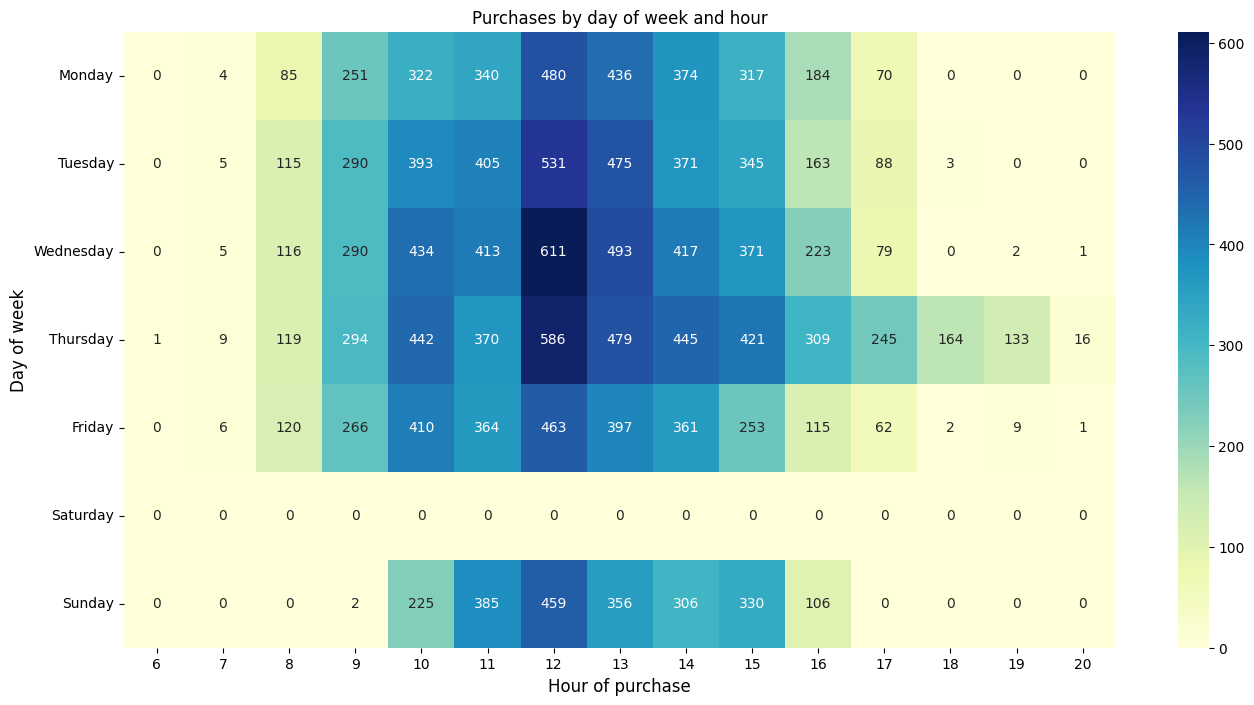

In [36]:
plt.figure(figsize=(16, 8))
ax = sns.heatmap(weekly_purchase_matrix, annot=True, cmap="YlGnBu", fmt="g")
ax.set_yticklabels(days_dict.values(), rotation=0)
plt.title("Purchases by day of week and hour")
plt.ylabel("Day of week", fontsize=12)
plt.xlabel("Hour of purchase", fontsize=12)
plt.show()

### Products Often Bought Together (Basket Analysis)

To increase sales without spending more on ads, we can simply recommend items that naturally go well together. Here, I am scanning all invoices to find the most common product pairs. 

This data can be directly used by the Product team to build a "Frequently Bought Together" widget on the website, which will easily increase the average basket size.

In [27]:
from itertools import combinations
from collections import Counter

product_dict = (
    df_no_cancel.drop_duplicates(subset=["StockCode"])
    .set_index("StockCode")["Description"]
    .to_dict()
)

transactions = df_no_cancel.groupby("InvoiceNo")["StockCode"].unique()

pair_counter = Counter()

for basket in transactions:
    if len(basket) > 1:
        pair_counter.update(combinations(sorted(basket), 2))
top_pairs = pair_counter.most_common(20)

top_pairs_df = pd.DataFrame(
    data=(
        (pair[0], product_dict.get(pair[0]), pair[1], product_dict.get(pair[1]), count)
        for pair, count in top_pairs
    ),
    columns=["StockCodeA", "ProductNameA", "StockCodeB", "ProductNameB", "PairCount"],
)
top_pairs_df.head(10)

,StockCodeA,ProductNameA,StockCodeB,ProductNameB,PairCount
0,22386,JUMBO BAG PINK POLKADOT,85099B,JUMBO BAG RED RETROSPOT,546
1,22697,GREEN REGENCY TEACUP AND SAUCER,22699,ROSES REGENCY TEACUP AND SAUCER,541
2,22726,ALARM CLOCK BAKELIKE GREEN,22727,ALARM CLOCK BAKELIKE RED,530
3,20725,LUNCH BAG RED RETROSPOT,22384,LUNCH BAG PINK POLKADOT,523
4,20725,LUNCH BAG RED RETROSPOT,22383,LUNCH BAG SUKI DESIGN,519
5,20725,LUNCH BAG RED RETROSPOT,20727,LUNCH BAG BLACK SKULL.,517
6,82482,WOODEN PICTURE FRAME WHITE FINISH,82494L,WOODEN FRAME ANTIQUE WHITE,468
7,23203,JUMBO BAG DOILEY PATTERNS,85099B,JUMBO BAG RED RETROSPOT,468
8,20725,LUNCH BAG RED RETROSPOT,22382,LUNCH BAG SPACEBOY DESIGN,467
9,20727,LUNCH BAG BLACK SKULL.,22383,LUNCH BAG SUKI DESIGN,465


### Key Takeaways & Recommendations: Customer Behaviour

#### The "Working Hours" Anomaly (Data Generation Artifact)
* **Observation:** The weekly heatmap shows almost zero transactions during weekends and evenings, with activity peaking heavily between 10:00 and 15:00 on weekdays. In an online e-commerce environment (which is available 24/7), this is highly unnatural for user behavior.
* **Recommendation:** This anomaly indicates that the `InvoiceDate` column records the moment the internal staff (warehouse or accounting) processes the order and generates the invoice, not the exact moment the customer placed the order online. To optimize marketing campaigns and send push notifications effectively, the Data Engineering team must provide access to frontend "Order Creation" timestamps. Relying solely on invoice generation times will mislead the Marketing department about true customer habits.

#### Basket Expansion via Product Pairing
* **Observation:** Basket analysis reveals very strong product pairings. Customers consistently buy matching items together (e.g., Pink and Red Jumbo Bags, or specific matching teacups).
* **Recommendation:** The Product team should implement a "Frequently Bought Together" widget on product pages and in the shopping cart. Automatically suggesting the matching item right before checkout will naturally increase the Average Order Value (AOV) without the need for heavy discounting.

## Geographic opportunities

### International Market Analysis (Excluding UK)

To understand our opportunities abroad, I am isolating the international data by removing the UK market. I also filter out countries with fewer than 20 customers to make sure our data is reliable and not skewed by single, random purchases. Finally, comparing both the average and median revenue will help us spot if a few big buyers are inflating the numbers.

In [31]:
arpu_summary = (
    df.loc[df["Country"] != "United Kingdom"]
    .groupby(["Country", "CustomerID"], as_index=False)
    .agg(TotalSpending=("TotalPrice", "sum"))
    .groupby("Country")
    .filter(lambda x: len(x) >= 20)
    .groupby("Country")
    .agg(
        AverageRevenuePerUser=("TotalSpending", "mean"),
        MedianRevenuePerUser=("TotalSpending","median"),
        UniqueCustomers=("CustomerID", "nunique"),
    )
    .sort_values(by="AverageRevenuePerUser", ascending=False)
    .round(2)
)

arpu_summary

,AverageRevenuePerUser,MedianRevenuePerUser,UniqueCustomers
Country,,,
Switzerland,2654.26,1628.12,21
Germany,2333.67,1013.26,95
France,2261.07,862.81,87
Spain,1766.92,806.27,31
Belgium,1636.44,1303.63,25


#### Top Markets are Driven by a Few Big Buyers
* **Observation:** In Germany and France, the average revenue is much higher than the median. This means most customers spend around £800-£1,000, but a few massive buyers are pushing the average up significantly.
* **Recommendation:** We need to identify these top buyers and offer them VIP treatment. Losing even one of them would heavily impact our revenue in these countries.

#### Belgium is a Stable Market
* **Observation:** In Belgium, the average revenue (£1,636) and the median (£1,303) are quite close to each other.
* **Recommendation:** This means customers in Belgium spend very similar amounts. It's a safe and predictable market, making it a great place to test new marketing campaigns without the risk of unpredictable results.